In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Define the CNN architecture
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # TODO 1: Define the layers of the CNN
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(16 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # TODO 2: Implement the forward pass
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 16 * 7 * 7)  # Flatten the tensor for the fully connected layer
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)


        return x

# TODO 3: Define the transformations for the dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# TODO 4: Load the MNIST dataset (Training)
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# TODO 5: Load the MNIST dataset (Testing)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)


# Initialize the network
net = CNN()

# TODO 6: Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

# Training loop
epochs = 10
train_losses = []
test_losses = []
train_accuracy = []
test_accuracy = []

for epoch in range(epochs):
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for i, data in enumerate(trainloader, 0):
        # TODO 7: Get the inputs and labels
        inputs, labels = data
        
        # TODO 8: Zero the parameter gradients
        optimizer.zero_grad()
        
        # TODO 9: Forward pass
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        
        # TODO 10: Backward pass
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # TODO 11: Compute the accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(trainloader))
    train_accuracy.append(correct_train / total_train)

    # Testing loop
    # TODO 12: Implement the testing loop
    test_loss = 0.0
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            outputs = net(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_losses.append(test_loss / len(testloader))
    test_accuracy.append(correct_test / total_test)

    print(f'Epoch [{epoch + 1}/{epochs}], '
          f'Train Loss: {train_losses[-1]:.4f}, '
          f'Test Loss: {test_losses[-1]:.4f}, '
          f'Train Accuracy: {train_accuracy[-1]:.4f}, '
          f'Test Accuracy: {test_accuracy[-1]:.4f}')

# Plotting the loss and accuracy curves
# TODO 13: Plot the loss and accuracy curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

ModuleNotFoundError: No module named 'torch'

In [ ]:
def count_parameters(model):
    """
    Function to count the total number of parameters in a PyTorch model.

    Parameters:
        model (torch.nn.Module): PyTorch model.

    Returns:
        total_params (int): Total number of parameters in the model.
    """
    # TODO 14: Implement the function to count the total number of parameters in the model
    # ...

# Example usage:
total_params = count_parameters(net)
print(f"Total number of parameters in the model: {total_params}")

Total number of parameters in the model: 103018


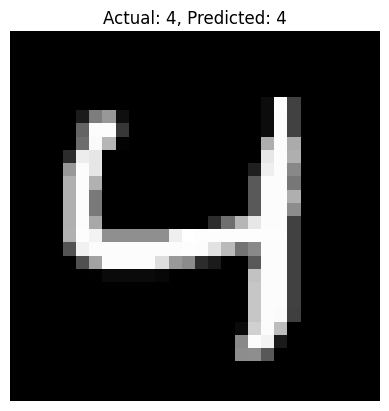

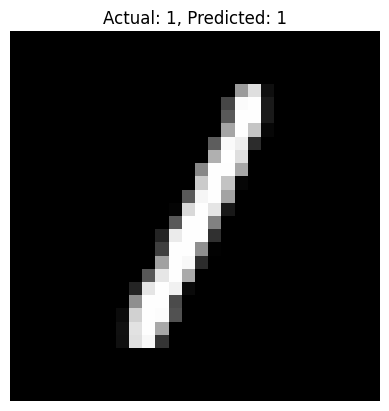

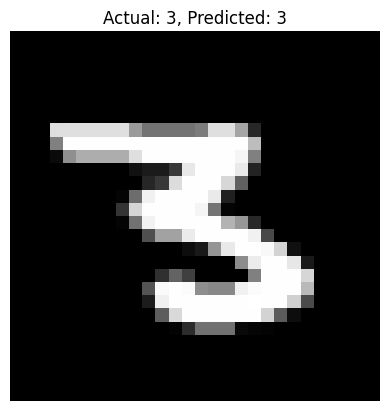

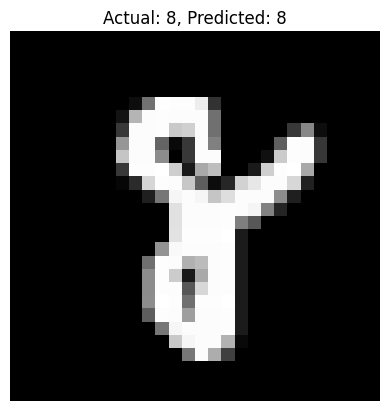

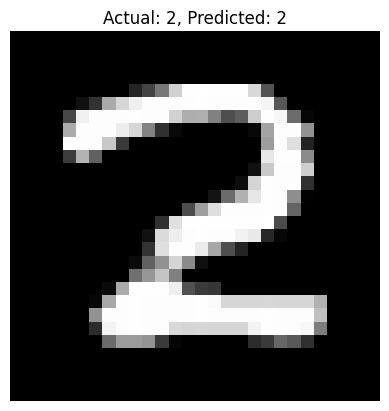

In [ ]:
import random

# Select random images from the test set
num_images_to_show = 5
random_indices = random.sample(range(len(testset)), num_images_to_show)

# Prepare for model evaluation
# TODO 15: Set the model to evaluation mode
# ...

# Make predictions and display images with predictions
with torch.no_grad():
    for idx in random_indices:
        # TODO 16: Get the image and label from the test set
        # ...

        plt.imshow(image.squeeze(), cmap='gray')
        plt.title(f'Actual: {label}, Predicted: {predicted.item()}')
        plt.axis('off')
        plt.show()
